# Analise de dados dos tickets base Kaggle

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('../../../data/rows.csv')
df

/tmp/ipykernel_14154/2901202569.py:1: DtypeWarning: Columns (4,5,6,11,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../../data/rows.csv')


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282350,12/01/2011,Credit card,NaN,Credit determination,NaN,NaN,NaN,"CITIBANK, N.A.",MO,63301,NaN,NaN,Web,12/02/2011,Closed with relief,Yes,No,2396
1282351,12/01/2011,Mortgage,Conventional fixed mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,"BANK OF AMERICA, NATIONAL ASSOCIATION",OH,45248,NaN,NaN,Web,12/06/2011,Closed without relief,No,No,2323
1282352,12/01/2011,Credit card,NaN,Billing disputes,NaN,NaN,NaN,JPMORGAN CHASE & CO.,OH,43207,NaN,NaN,Referral,12/01/2011,Closed with relief,Yes,No,2126
1282353,12/01/2011,Mortgage,Conventional adjustable mortgage (ARM),"Loan servicing, payments, escrow account",NaN,NaN,NaN,"BANK OF AMERICA, NATIONAL ASSOCIATION",CO,80920,NaN,NaN,Web,12/01/2011,Closed with relief,Yes,No,2315


# Tratamento de dados

In [21]:
# converter datas
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
df['Date sent to company'] = pd.to_datetime(df['Date sent to company'], errors='coerce')

In [22]:
# remover linhas sem datas
df = df.dropna(subset=['Date received', 'Date sent to company'])

In [23]:
# criando colunas auxiliares
df['year'] = df['Date received'].dt.year
df['month'] = df['Date received'].dt.month
df['day'] = df['Date received'].dt.day
df['date'] = df['Date received'].dt.to_period('D').dt.to_timestamp()

In [24]:
# agrupamento por data
daily_tickets = df.groupby('date').size().rename('ticket_count').reset_index()

In [25]:
# agrupamento por mês
monthly_tickets = df.groupby(df['Date received'].dt.to_period('M')).size().rename('ticket_count').reset_index()
monthly_tickets['Date received'] = monthly_tickets['Date received'].dt.to_timestamp()

In [26]:
# analise de tempo resposta dos tickets
df['response_time_days'] = (df['Date sent to company'] - df['Date received']).dt.days

In [27]:
# remover outliers negativos e absurdos
df = df[(df['response_time_days'] >= 0) & (df['response_time_days'] <= 60)]

In [34]:
# sazonalidade
seasonality = df.groupby(['year', 'month']).size().unstack(fill_value=0)

# Analises temporais

### tendência de tickets diária

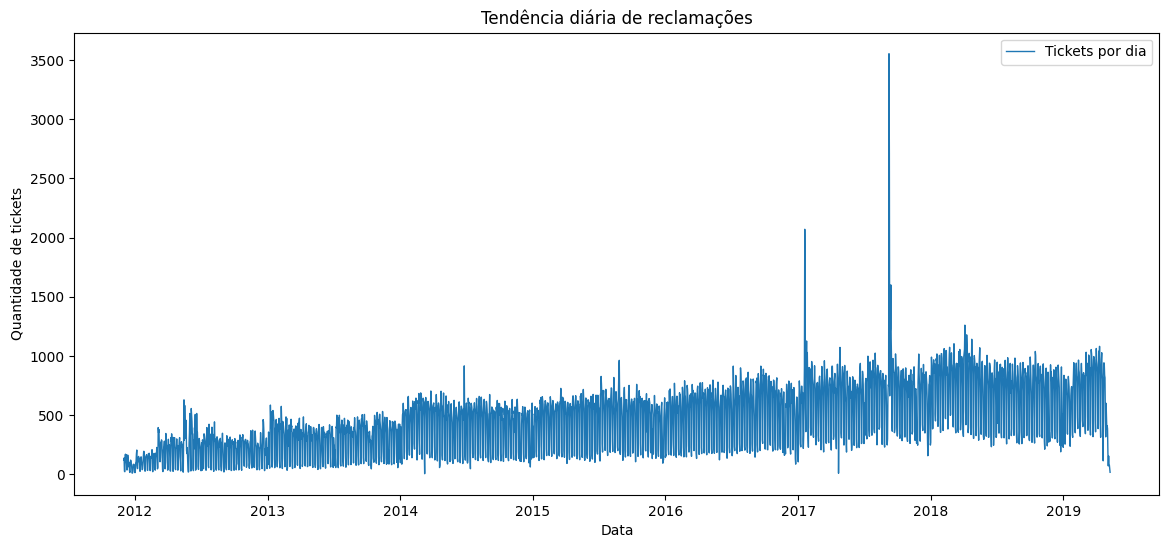

In [28]:
plt.figure(figsize=(14,6))
plt.plot(daily_tickets['date'], daily_tickets['ticket_count'], label='Tickets por dia', linewidth=1)
plt.title('Tendência diária de reclamações')
plt.xlabel('Data')
plt.ylabel('Quantidade de tickets')
plt.legend()
plt.show()

# tendência de tickets mensal

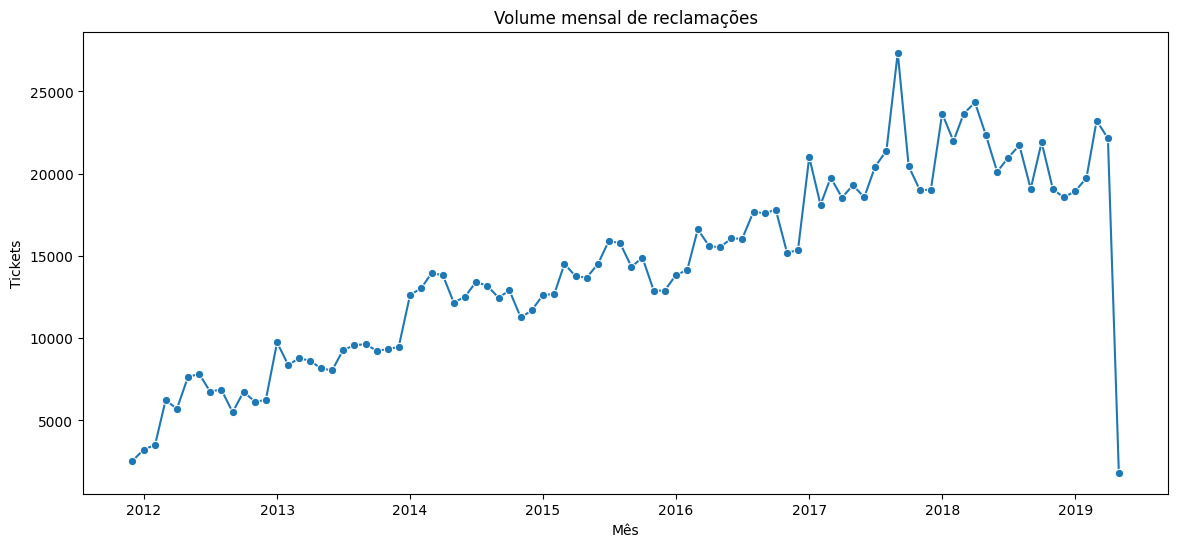

In [29]:
plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_tickets, x='Date received', y='ticket_count', marker='o')
plt.title('Volume mensal de reclamações')
plt.xlabel('Mês')
plt.ylabel('Tickets')
plt.show()

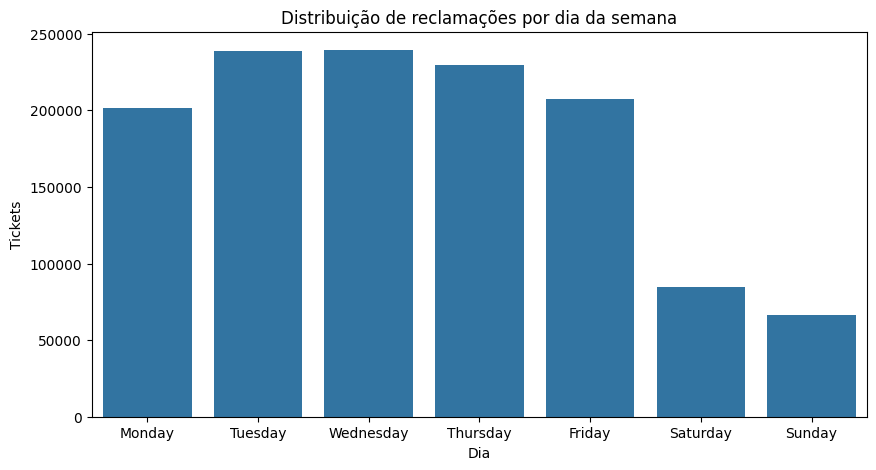

In [30]:
# agrupamento por dia da semana
df['weekday'] = df['Date received'].dt.day_name()
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='weekday', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Distribuição de reclamações por dia da semana')
plt.xlabel('Dia')
plt.ylabel('Tickets')
plt.show()

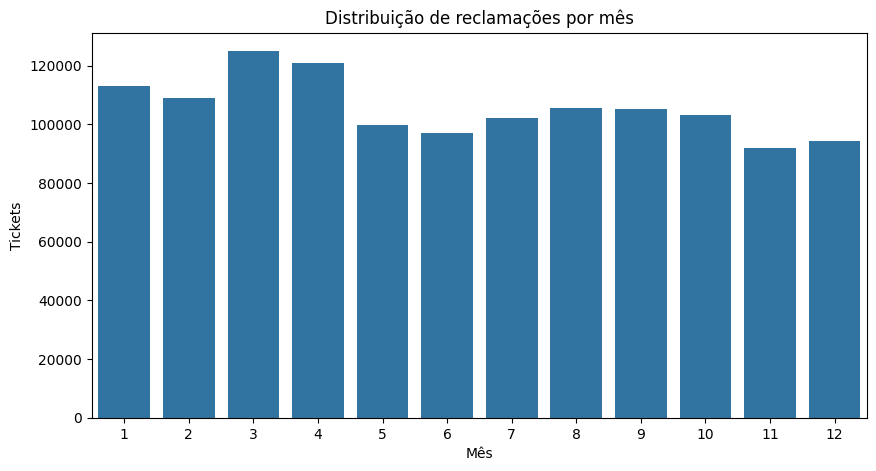

In [31]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='month')
plt.title('Distribuição de reclamações por mês')
plt.xlabel('Mês')
plt.ylabel('Tickets')
plt.show()

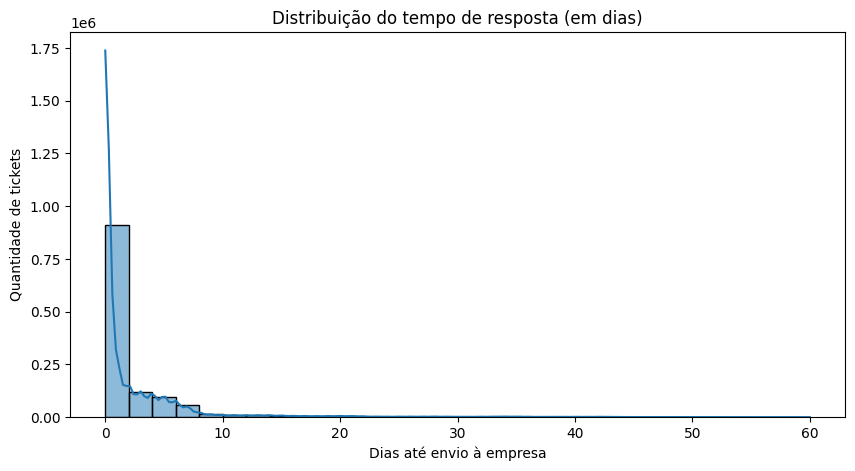


Tempo médio de resposta (dias): 2.33


In [33]:
plt.figure(figsize=(10,5))
sns.histplot(df['response_time_days'], bins=30, kde=True)
plt.title('Distribuição do tempo de resposta (em dias)')
plt.xlabel('Dias até envio à empresa')
plt.ylabel('Quantidade de tickets')
plt.show()

print('\nTempo médio de resposta (dias):', round(df['response_time_days'].mean(), 2))

# analise de sazonalidade

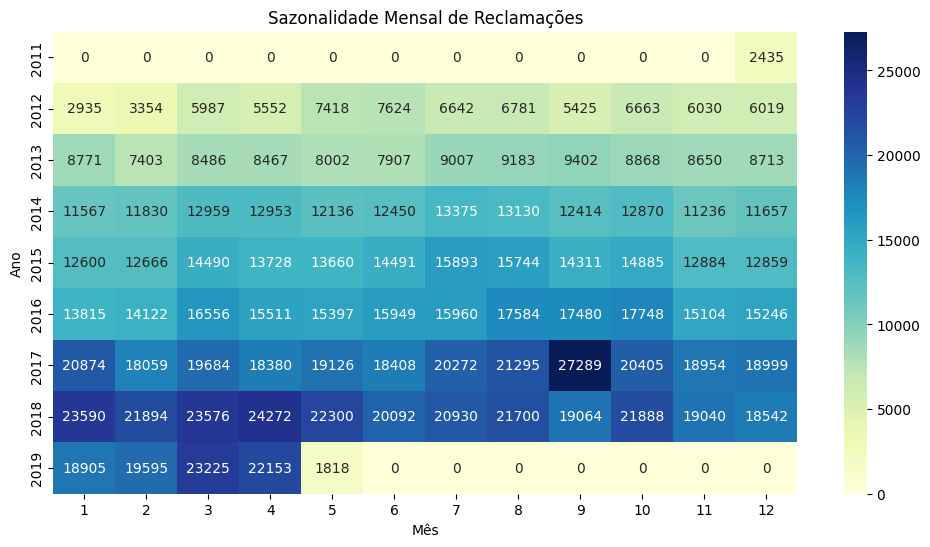

In [38]:
# sazonalidade
plt.figure(figsize=(12,6))
sns.heatmap(seasonality, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Sazonalidade Mensal de Reclamações')
plt.xlabel('Mês')
plt.ylabel('Ano')
plt.show()

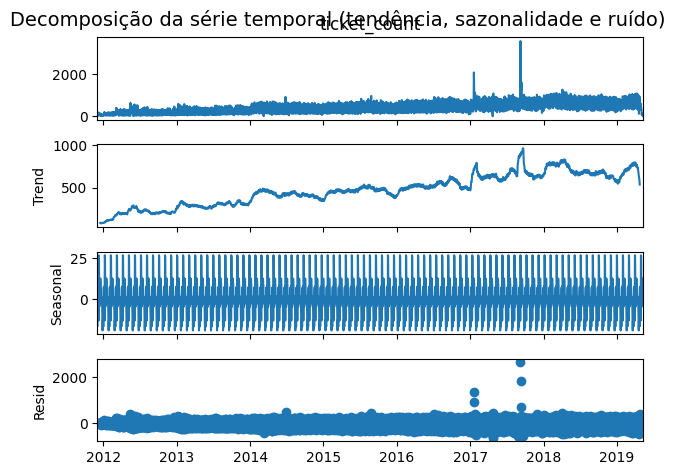

In [ ]:
# análise de sazonalidade usando decomposição
from statsmodels.tsa.seasonal import seasonal_decompose

# Série temporal diária
ts = daily_tickets.set_index('date')['ticket_count'].asfreq('D').fillna(0)

result = seasonal_decompose(ts, model='additive', period=30)
result.plot()
plt.suptitle('Decomposição da série temporal (tendência, sazonalidade e ruído)', fontsize=14)
plt.show()